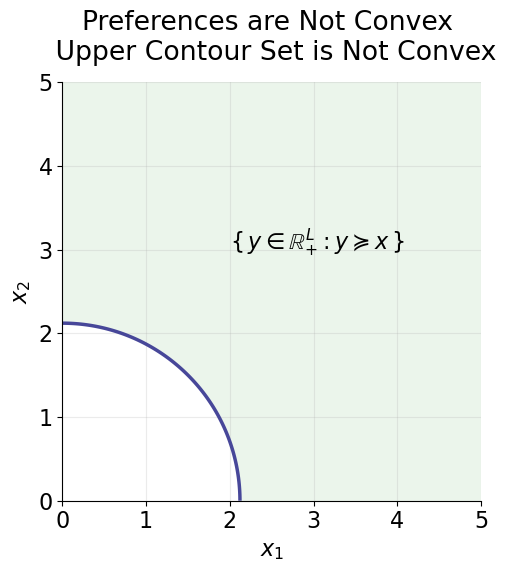

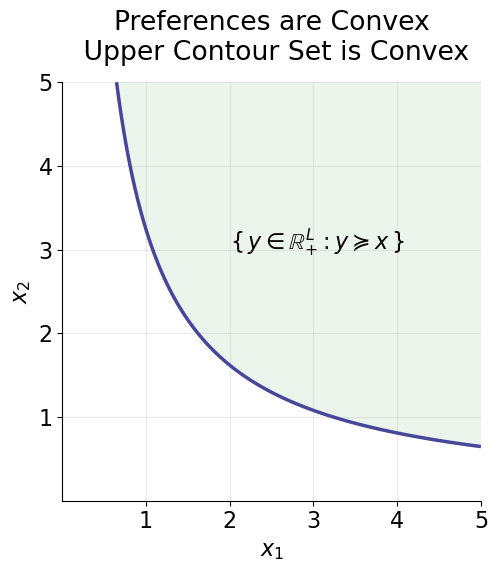

In [15]:
# Fix titles order and replace the third title line (remove "Only u=1.8; shaded region")
# New third lines:
#   - For U_concave: "Preferences are Not Convex -> Upper Contour Set is Not Convex"
#   - For U_convex:  "Preferences are Convex -> Upper Contour Set is Convex"

import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 16})

def blend_with_white(rgb, t):
    r,g,b = rgb
    return (1 - t) * 1.0 + t * r, (1 - t) * 1.0 + t * g, (1 - t) * 1.0 + t * b

# Colors
ChadBlue = (0.1, 0.1, 0.5)
levels = [0.5, 0.8, 1.2, 1.8, 2.6]
t_values = [0.35, 0.50, 0.65, 0.80, 1.00]
colors = [blend_with_white(ChadBlue, t) for t in t_values]

u_level = 1.8
curve_color = colors[levels.index(u_level)]

ChadGreen = (0.0, 0.5, 0.0)
green_with_alpha = (ChadGreen[0], ChadGreen[1], ChadGreen[2], 0.08)

manual_positions = [(u_level, u_level)]

def U_concave(x1, x2):
    return (2/5)*(x1**2 + x2**2)

def U_convex(x1, x2):
    return np.sqrt(x1 * x2)

# Grids
x1 = np.linspace(0.0, 5.0, 700)
x2 = np.linspace(0.0, 5.0, 700)
X1, X2 = np.meshgrid(x1, x2)
U_c = U_concave(X1, X2)

x1b = np.linspace(0.001, 5.0, 700)
x2b = np.linspace(0.001, 5.0, 700)
X1b, X2b = np.meshgrid(x1b, x2b)
U_v = U_convex(X1b, X2b)

# U_concave plot (upper contour set is NOT convex)
plt.rcParams.update({'font.size': 16})
plt.figure(figsize=(7, 6))
CS1 = plt.contour(X1, X2, U_c, levels=[u_level], colors=[curve_color], linewidths=2.5)
plt.contourf(X1, X2, U_c, levels=[u_level, U_c.max()+1], colors=[green_with_alpha])
plt.xlabel(r"$x_1$", color="black")
plt.ylabel(r"$x_2$", color="black")
plt.title("Preferences are Not Convex \n Upper Contour Set is Not Convex", pad=16)
plt.text(2, 3, r"$\{\,y \in \mathbb{R}^L_{+} : y \succeq x \,\}$", fontsize=16)
plt.grid(True, alpha=0.25)
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.axis("scaled")
plt.tight_layout()
plt.savefig("concave.png", dpi=600)
plt.show()

# U_convex plot (upper contour set IS convex)
plt.figure(figsize=(7, 6))
CS2 = plt.contour(X1b, X2b, U_v, levels=[u_level], colors=[curve_color], linewidths=2.5)
plt.contourf(X1b, X2b, U_v, levels=[u_level, U_v.max()+1], colors=[green_with_alpha])
plt.xlabel(r"$x_1$", color="black")
plt.ylabel(r"$x_2$", color="black")
plt.title("Preferences are Convex\n Upper Contour Set is Convex", pad=16)
plt.text(2, 3, r"$\{\,y \in \mathbb{R}^L_{+} : y \succeq x \,\}$")

plt.grid(True, alpha=0.25)
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.axis("scaled")
plt.tight_layout()
plt.savefig("convex.png", dpi=600)
plt.show()

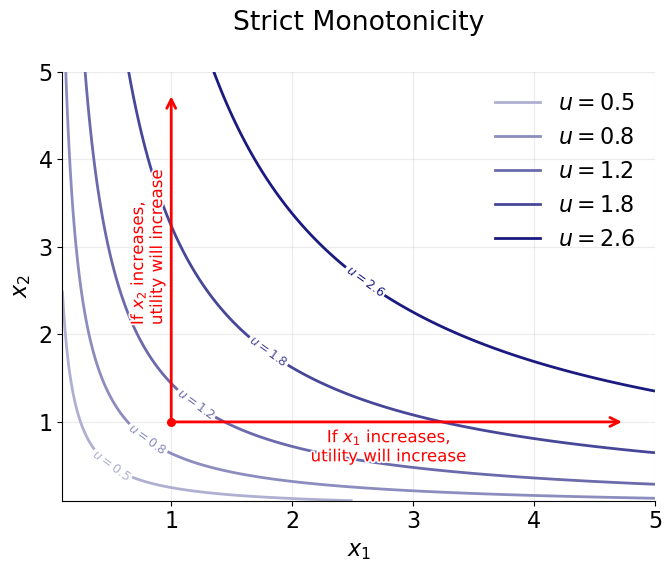

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patheffects as path_effects

# ---------- Color utility ----------
def blend_with_white(rgb, t):
    white = np.array([1.0, 1.0, 1.0])
    base = np.array(rgb)
    out = (1 - t) * white + t * base
    return tuple(out.tolist())

# ---------- Colors & levels ----------
ChadBlue = (0.1, 0.1, 0.5)
levels = [0.5, 0.8, 1.2, 1.8, 2.6]
t_values = [0.35, 0.50, 0.65, 0.80, 1.00]
colors = [blend_with_white(ChadBlue, t) for t in t_values]

# ---------- Domain + utility ----------
x1 = np.linspace(0.1, 5, 400)
x2 = np.linspace(0.1, 5, 400)
X1, X2 = np.meshgrid(x1, x2)
U = np.sqrt(X1 * X2)

# ---------- Plot ----------
plt.figure(figsize=(7, 6))
CS = plt.contour(X1, X2, U, levels=levels, colors=colors, linewidths=2)

# Label formatting and positions at (u, u) along the diagonal x1=x2
manual_labels = {0.5:"$u=0.5$", 0.8:"$u=0.8$", 1.2:"$u=1.2$", 1.8:"$u=1.8$", 2.6:"$u=2.6$"}
manual_positions = [(u, u) for u in levels]
plt.clabel(
    CS,
    inline=True,
    inline_spacing=1,        # tighter = more centered appearance
    use_clabeltext=True,
    fontsize=9,
    fmt=manual_labels,
    manual=manual_positions  # anchor labels on the diagonal
)

# ---------- Red arrows from (1,1) ----------
plt.scatter([1], [1], s=30, color="red", zorder=5)
plt.annotate("", xy=(1, 4.75), xytext=(1, 1),
             arrowprops=dict(arrowstyle="->", color="red", lw=2))
plt.annotate("", xy=(4.75, 1), xytext=(1, 1),
             arrowprops=dict(arrowstyle="->", color="red", lw=2))

# ---------- Explanatory red text (minimal padding, white outline) ----------
txt1 = plt.text(
    2.8, 0.55, "If $x_1$ increases,\nutility will increase",
    color="red", fontsize=12, ha="center"
)
txt2 = plt.text(
    0.65, 3.0, "If $x_2$ increases,\nutility will increase",
    color="red", fontsize=12, va="center", rotation=90
)
for t in [txt1, txt2]:
    t.set_path_effects([
        path_effects.Stroke(linewidth=2.5, foreground="white"),
        path_effects.Normal()
    ])

# ---------- Axes, title, legend ----------
plt.xlabel(r"$x_1$", color="black")
plt.ylabel(r"$x_2$", color="black")
plt.title("Strict Monotonicity", pad=30)
plt.grid(True, alpha=0.25)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

handles2d = [Line2D([0],[0], color=colors[i], lw=2, label=manual_labels[levels[i]])
             for i in range(len(levels))]
plt.legend(handles=handles2d, loc="upper right", frameon=False)

plt.tight_layout()
plt.savefig("monotonicity.png", dpi=600, bbox_inches="tight")
plt.show()
